In [1]:

import itertools, math, random, time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix, r2_score

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
device = torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)
print("device:", device, "seed:", SEED)


device: cpu seed: 13


## 1. Configuration

In [2]:

# =========================
# Data / simulation
# =========================
N = 300
TRAIN_L = 90
TEST_L = TRAIN_L          # <-- change this to test a different recording duration
N_TEST = 80

L = TRAIN_L               # Block-1 code uses L internally
p = 40
A = D = 3
K_DATA = 2
K_FIT = 2                 # any integer >= K_DATA

I_CONDITIONS = np.array([
    [0,0,0], [1,0,0], [0,1,0], [0,0,1]
], dtype=np.float32)

# observation model
OBS_NONLINEAR_STRENGTH = 0.10
OBS_NOISE_SD = 0.03

# =========================
# Block 1: v113 representation / mixture-particle update
# =========================
MAX_OUTER = 32
LR_REP = 4e-4
LR_MILESTONES = [10, 20, 28]  # absolute; never depends on MAX_OUTER
LR_GAMMA = 0.25
RECON_SIGMA = 0.20
BETA_ID = 1.0
BETA_DYN = 0.008

RIDGE = 1e-3
VAL_FRAC = 0.25
LAMBDA_LAG_SCORE = 0.001
LAMBDA_INST_SCORE = 0.001

RESP_TEMP = 1.0
PI_ALPHA = 1.0
RESP_FLOOR = 1e-4
MIN_EFFECTIVE_N = 12.0
DEAD_PATIENCE = 3

GRAPH_MOVES_PER_OUTER = 3
TAU_GRAPH = 4e-4
ETA_H = 0.65
TAU_H = 0.60
TAU_LOGVAR = 0.02

# =========================
# Block 2: online conditional FM
# =========================
FM_CONTEXT_DIM = 96
FM_HIDDEN = 192
FM_LR = 1e-3
FM_UPDATES_PER_OUTER = 20
FM_BATCH = 48

# No extra G/H perturbation in Block 2.
# Diversity comes from Block-1 particles + simulation randomness.
FM_SIM_REPS_PER_COMPONENT_INTERVENTION = 3

# Train the conditioner on multiple recording lengths.
# If TEST_L is far outside this range, extend this list.
FM_SIM_LENGTHS = sorted(set([
    max(20, TRAIN_L // 2),
    TRAIN_L,
    int(round(1.5 * TRAIN_L)),
]))

FM_GRAPH_EPS = 0.02
FM_LAMBDA_LAG = 1.0
FM_LAMBDA_INST = 1.0
FM_LAMBDA_H = 1.0

# H normalization: fixed, not data-dependent and not changing across outer iterations
H_COEF_SCALE = 1.0
H_LOGVAR_SCALE = 3.0
H_INT_MEAN_SCALE = 2.0

# posterior generation
FM_GEN_STEPS = 100
FM_GEN_RATE_SCALE = 2.0
FM_SAMPLES_PER_TEST = 3

print({
    "K_DATA": K_DATA,
    "K_FIT": K_FIT,
    "TRAIN_L": TRAIN_L,
    "TEST_L": TEST_L,
    "FM_SIM_LENGTHS": FM_SIM_LENGTHS,
})


{'K_DATA': 2, 'K_FIT': 2, 'TRAIN_L': 90, 'TEST_L': 90, 'FM_SIM_LENGTHS': [45, 90, 135]}


## 2. Two-regime latent temporal simulation

In [3]:

def adj_from_edges(edges, d=A):
    G = np.zeros((d,d), dtype=np.float32)
    for u,v in edges:
        G[u,v] = 1.0
    return G

def is_dag(G):
    G = (G > .5).astype(int)
    indeg = G.sum(0).astype(int).tolist()
    q = [j for j in range(len(G)) if indeg[j] == 0]
    seen = 0
    while q:
        u = q.pop(0); seen += 1
        for v in range(len(G)):
            if G[u,v]:
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
    return seen == len(G)

def topo_order(G):
    G = (G > .5).astype(int)
    indeg = G.sum(0).astype(int).tolist()
    q = [j for j in range(len(G)) if indeg[j] == 0]
    out = []
    while q:
        u = q.pop(0); out.append(u)
        for v in range(len(G)):
            if G[u,v]:
                indeg[v] -= 1
                if indeg[v] == 0: q.append(v)
    if len(out) != len(G): raise ValueError("not DAG")
    return out

TRUE_LAG = [
    adj_from_edges([(0,1),(0,2),(1,2)]),
    adj_from_edges([(2,1),(2,0),(1,0)]),
]
TRUE_INST = [
    adj_from_edges([(0,1),(1,2)]),
    adj_from_edges([(2,1),(1,0)]),
]

TRUE_PI = np.array([0.55, 0.45])

true_bias = [
    np.array([0.45,-0.40,0.30], np.float32),
    np.array([-0.45,0.40,-0.30], np.float32),
]
true_self = [
    np.array([0.55,0.45,0.50], np.float32),
    np.array([0.48,0.52,0.42], np.float32),
]
true_lag_coef = [np.zeros((A,A),np.float32) for _ in range(K_DATA)]
true_inst_coef = [np.zeros((A,A),np.float32) for _ in range(K_DATA)]
true_lag_coef[0][0,1]=.80; true_lag_coef[0][0,2]=-.60; true_lag_coef[0][1,2]=.70
true_inst_coef[0][0,1]=.65; true_inst_coef[0][1,2]=-.55
true_lag_coef[1][2,1]=-.75; true_lag_coef[1][2,0]=.65; true_lag_coef[1][1,0]=-.70
true_inst_coef[1][2,1]=.60; true_inst_coef[1][1,0]=.55

true_noise_sd = [
    np.array([.20,.20,.20],np.float32),
    np.array([.22,.19,.21],np.float32),
]
true_int_mean = np.array([-2.0,2.0,-1.5],np.float32)
true_int_sd = np.array([.30,.30,.30],np.float32)

rng_sim = np.random.default_rng(SEED)
R_true = rng_sim.choice(K_DATA, size=N, p=TRUE_PI)
I_index = rng_sim.integers(0, len(I_CONDITIONS), size=N)
I_np = I_CONDITIONS[I_index].astype(np.float32)

Z_true_np = np.zeros((N,L,A),np.float32)
Z_true_np[:,0] = rng_sim.normal(size=(N,A)).astype(np.float32)

for i in range(N):
    r = int(R_true[i])
    order = topo_order(TRUE_INST[r])
    for t in range(1,L):
        prev = Z_true_np[i,t-1]
        curr = np.zeros(A,np.float32)
        for a in order:
            if I_np[i,a] > .5:
                curr[a] = rng_sim.normal(true_int_mean[a], true_int_sd[a])
            else:
                mu = true_bias[r][a] + true_self[r][a]*prev[a]
                for k in range(A):
                    if TRUE_LAG[r][k,a] > .5:
                        mu += true_lag_coef[r][k,a]*np.tanh(prev[k])
                    if TRUE_INST[r][k,a] > .5:
                        mu += true_inst_coef[r][k,a]*np.tanh(curr[k])
                curr[a] = rng_sim.normal(mu, true_noise_sd[r][a])
        Z_true_np[i,t] = curr

print("regime counts:", np.bincount(R_true))
for r in range(K_DATA):
    print(f"regime {r+1} lag\n", TRUE_LAG[r].astype(int))
    print(f"regime {r+1} inst\n", TRUE_INST[r].astype(int))


regime counts: [168 132]
regime 1 lag
 [[0 1 1]
 [0 0 1]
 [0 0 0]]
regime 1 inst
 [[0 1 0]
 [0 0 1]
 [0 0 0]]
regime 2 lag
 [[0 0 0]
 [1 0 0]
 [1 1 0]]
regime 2 inst
 [[0 0 0]
 [1 0 0]
 [0 1 0]]


## 3. Shared observation model and train/validation split

In [4]:

rng_obs = np.random.default_rng(SEED+200)
B_linear = rng_obs.normal(size=(A,p)).astype(np.float32)
U,_,Vt = np.linalg.svd(B_linear, full_matrices=False)
B_linear = (2.0*(U@Vt)).astype(np.float32)
W_nonlin = rng_obs.normal(0,.8,size=(A,24)).astype(np.float32)
B_nonlin = rng_obs.normal(0,1/np.sqrt(24),size=(24,p)).astype(np.float32)

Y_np = (
    Z_true_np@B_linear
    + OBS_NONLINEAR_STRENGTH*(np.tanh(Z_true_np@W_nonlin)@B_nonlin)
    + rng_obs.normal(0,OBS_NOISE_SD,size=(N,L,p)).astype(np.float32)
)
ym = Y_np.reshape(-1,p).mean(0,keepdims=True)
ys = Y_np.reshape(-1,p).std(0,keepdims=True)+1e-6
Y_np = ((Y_np-ym)/ys).astype(np.float32)

rng_split = np.random.default_rng(SEED+11)
idx = np.arange(N); rng_split.shuffle(idx)
n_val = int(round(VAL_FRAC*N))
val_idx, train_idx = idx[:n_val], idx[n_val:]

Y = torch.tensor(Y_np,dtype=torch.float32,device=device)
I_torch = torch.tensor(I_np,dtype=torch.float32,device=device)
print("Y",Y_np.shape,"train/val",len(train_idx),len(val_idx))


Y (300, 90, 40) train/val 225 75


## 3.1 Independent test trajectories with user-controlled recording length

In [5]:

def simulate_true_dataset(n, length, rng, pi=TRUE_PI):
    labels = rng.choice(K_DATA, size=n, p=pi)
    i_idx = rng.integers(0, len(I_CONDITIONS), size=n)
    I_out = I_CONDITIONS[i_idx].astype(np.float32)
    Z_out = np.zeros((n, length, A), np.float32)
    Z_out[:,0] = rng.normal(size=(n,A)).astype(np.float32)

    for i in range(n):
        r = int(labels[i])
        order = topo_order(TRUE_INST[r])
        for t in range(1, length):
            prev = Z_out[i,t-1]
            curr = np.zeros(A, np.float32)
            for a in order:
                if I_out[i,a] > .5:
                    curr[a] = rng.normal(true_int_mean[a], true_int_sd[a])
                else:
                    mu = true_bias[r][a] + true_self[r][a] * prev[a]
                    for k in range(A):
                        if TRUE_LAG[r][k,a] > .5:
                            mu += true_lag_coef[r][k,a] * np.tanh(prev[k])
                        if TRUE_INST[r][k,a] > .5:
                            mu += true_inst_coef[r][k,a] * np.tanh(curr[k])
                    curr[a] = rng.normal(mu, true_noise_sd[r][a])
            Z_out[i,t] = curr
    return Z_out, I_out, labels

def observe_true_latents(Zin, rng):
    Yraw = (
        Zin @ B_linear
        + OBS_NONLINEAR_STRENGTH * (np.tanh(Zin @ W_nonlin) @ B_nonlin)
        + rng.normal(0, OBS_NOISE_SD, size=(*Zin.shape[:-1], p)).astype(np.float32)
    )
    return ((Yraw - ym) / ys).astype(np.float32)

rng_test = np.random.default_rng(SEED + 555)
Z_test_true_np, I_test_np, R_test_true = simulate_true_dataset(
    N_TEST, TEST_L, rng_test
)
Y_test_np = observe_true_latents(Z_test_true_np, rng_test)

print("test Y:", Y_test_np.shape)
print("test regime counts:", np.bincount(R_test_true, minlength=K_DATA))


test Y: (80, 90, 40)
test regime counts: [42 38]


## 4. Encoder, decoder, and coordinate identification

In [6]:

class LinearPCAEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        pca = PCA(n_components=D,random_state=SEED).fit(Y_np[train_idx].reshape(-1,p))
        self.linear = nn.Linear(p,D)
        with torch.no_grad():
            self.linear.weight.copy_(torch.tensor(pca.components_,dtype=torch.float32))
            self.linear.bias.copy_(torch.tensor(-pca.mean_@pca.components_.T,dtype=torch.float32))
    def forward(self,y): return self.linear(y)

class ResidualDecoder(nn.Module):
    def __init__(self,encoder):
        super().__init__()
        self.base=nn.Linear(D,p)
        with torch.no_grad():
            yf=Y_np[train_idx].reshape(-1,p)
            xf=encoder(torch.tensor(yf,dtype=torch.float32)).numpy()
            Xd=np.c_[xf,np.ones(len(xf))]
            b=np.linalg.lstsq(Xd,yf,rcond=None)[0]
            self.base.weight.copy_(torch.tensor(b[:-1].T,dtype=torch.float32))
            self.base.bias.copy_(torch.tensor(b[-1],dtype=torch.float32))
        self.res=nn.Sequential(nn.Linear(D,32),nn.SiLU(),nn.Linear(32,32),nn.SiLU(),nn.Linear(32,p))
        nn.init.zeros_(self.res[-1].weight); nn.init.zeros_(self.res[-1].bias)
    def forward(self,x): return self.base(x)+.10*self.res(x)

def init_models():
    torch.manual_seed(SEED)
    enc=LinearPCAEncoder().to(device); dec=ResidualDecoder(enc).to(device)
    opt=torch.optim.AdamW(list(enc.parameters())+list(dec.parameters()),lr=LR_REP,weight_decay=1e-6)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,milestones=LR_MILESTONES,gamma=LR_GAMMA)
    return enc,dec,opt,sch

def encode_all_np(enc):
    enc.eval()
    with torch.no_grad():
        X=enc(Y.reshape(-1,p)).reshape(N,L,D).cpu().numpy().astype(np.float64)
    enc.train(); return X

def whitening_from_training(X):
    v=X[train_idx].reshape(-1,D); m=v.mean(0)
    C=np.cov(v-m,rowvar=False)+1e-6*np.eye(D)
    e,V=np.linalg.eigh(C); Q=V@np.diag(1/np.sqrt(e))@V.T
    return m,Q

def mechanism_break_update(Xw,Wprev=None):
    rows=[]
    for a in range(A):
        active=train_idx[I_np[train_idx,a]>.5]
        cur=Xw[active,1:].reshape(-1,D); pre=Xw[active,:-1].reshape(-1,D)
        cur-=cur.mean(0); pre-=pre.mean(0)
        C=cur.T@pre/max(len(cur)-1,1)
        U,_,_=np.linalg.svd(C,full_matrices=True)
        w=U[:,-1]
        if Wprev is not None and np.dot(w,Wprev[a])<0: w=-w
        rows.append(w)
    W=np.stack(rows); W/=np.linalg.norm(W,axis=1,keepdims=True)+1e-12
    return W

def transform_all(X,Wprev=None):
    xm,Q=whitening_from_training(X); Xw=(X-xm)@Q
    W=mechanism_break_update(Xw,Wprev)
    Zraw=Xw@W.T
    base=train_idx[I_np[train_idx].sum(1)==0]
    zm=Zraw[base].reshape(-1,A).mean(0)
    zs=Zraw[base].reshape(-1,A).std(0)+1e-8
    return dict(X=X,Xw=Xw,xm=xm,Q=Q,W=W,zm=zm,zs=zs,Z=(Zraw-zm)/zs)


## 5. Enumerated joint graph state space

In [7]:

def enumerate_lag():
    edges=[(i,j) for i in range(A) for j in range(A) if i!=j]
    out=[]
    for bits in itertools.product([0,1],repeat=len(edges)):
        G=np.zeros((A,A),np.float32)
        for b,e in zip(bits,edges): G[e]=b
        out.append(G)
    return out

def enumerate_inst():
    edges=[(i,j) for i in range(A) for j in range(A) if i!=j]
    out=[]
    for bits in itertools.product([0,1],repeat=len(edges)):
        G=np.zeros((A,A),np.float32)
        for b,e in zip(bits,edges): G[e]=b
        if is_dag(G): out.append(G)
    return out

LAG_GRAPHS=enumerate_lag(); INST_GRAPHS=enumerate_inst()
GRAPH_PAIRS=[]; PAIR_LOOKUP={}
for Gl in LAG_GRAPHS:
    for Gi in INST_GRAPHS:
        j=len(GRAPH_PAIRS); GRAPH_PAIRS.append((Gl.copy(),Gi.copy()))
        PAIR_LOOKUP[(Gl.astype(np.int8).tobytes(),Gi.astype(np.int8).tobytes())]=j

def ptuple(G,a): return tuple(np.where(G[:,a]>.5)[0].tolist())
def pair_index(Gl,Gi): return PAIR_LOOKUP[(Gl.astype(np.int8).tobytes(),Gi.astype(np.int8).tobytes())]

def neighbors(j):
    Gl,Gi=GRAPH_PAIRS[j]; out={j}
    for u in range(A):
        for v in range(A):
            if u==v: continue
            x=Gl.copy(); x[u,v]=1-x[u,v]; out.add(pair_index(x,Gi))
            x=Gi.copy(); x[u,v]=1-x[u,v]
            if is_dag(x): out.add(pair_index(Gl,x))
            if Gi[u,v]>.5:
                x=Gi.copy(); x[u,v]=0; x[v,u]=1
                if is_dag(x): out.add(pair_index(Gl,x))
    return np.array(sorted(out),int)

GRAPH_NEIGHBORS=[neighbors(j) for j in range(len(GRAPH_PAIRS))]
TRUE_PAIR_INDEX=[pair_index(TRUE_LAG[r],TRUE_INST[r]) for r in range(K_DATA)]
print("graph pairs:",len(GRAPH_PAIRS),"true indices:",TRUE_PAIR_INDEX)


graph pairs: 1600 true indices: [1321, 282]


## 6. Responsibility-weighted v111 mechanism fitting and scoring

In [8]:

def local_design(zp,zc,lp,ip,a):
    cols=[np.ones(len(zp)),zp[:,a]]
    cols += [np.tanh(zp[:,k]) for k in lp]
    cols += [np.tanh(zc[:,k]) for k in ip]
    return np.stack(cols,1)

def weighted_ridge(Xd,y,w):
    w=np.clip(w,1e-8,None)
    XtW=Xd.T*w
    P=XtW@Xd+RIDGE*np.eye(Xd.shape[1])
    b=np.linalg.solve(P,XtW@y)
    res=y-Xd@b
    var=float(np.clip(np.sum(w*res**2)/np.sum(w),.05**2,2.0**2))
    cov=var*np.linalg.inv(P)
    return b,var,cov

def fit_component_cache(Z,gamma_col):
    cache={}
    for split_name,ids in [("tr",train_idx),("va",val_idx)]:
        pass
    zp_tr=Z[train_idx,:-1].reshape(-1,A); zc_tr=Z[train_idx,1:].reshape(-1,A)
    it_tr=np.repeat(I_np[train_idx],L-1,axis=0)
    wt_tr=np.repeat(gamma_col[train_idx],L-1)
    zp_va=Z[val_idx,:-1].reshape(-1,A); zc_va=Z[val_idx,1:].reshape(-1,A)
    it_va=np.repeat(I_np[val_idx],L-1,axis=0)
    wt_va=np.repeat(gamma_col[val_idx],L-1)

    for a in range(A):
        other=[k for k in range(A) if k!=a]
        for lb in itertools.product([0,1],repeat=len(other)):
            lp=tuple(k for k,b in zip(other,lb) if b)
            for ib in itertools.product([0,1],repeat=len(other)):
                ip=tuple(k for k,b in zip(other,ib) if b)
                obs=it_tr[:,a]<.5
                Xd=local_design(zp_tr[obs],zc_tr[obs],lp,ip,a)
                y=zc_tr[obs,a]; w=wt_tr[obs]
                beta,var,cov=weighted_ridge(Xd,y,w)
                ints=~obs; yi=zc_tr[ints,a]; wi=wt_tr[ints]
                im=float(np.sum(wi*yi)/(np.sum(wi)+1e-12))
                iv=float(np.clip(np.sum(wi*(yi-im)**2)/(np.sum(wi)+1e-12),.05**2,2.0**2))

                obv=it_va[:,a]<.5
                Xv=local_design(zp_va[obv],zc_va[obv],lp,ip,a)
                yv=zc_va[obv,a]; wv=wt_va[obv]
                ll=-.5*(np.log(2*np.pi*var)+(yv-Xv@beta)**2/var)
                inv=~obv; yvi=zc_va[inv,a]; wvi=wt_va[inv]
                lli=-.5*(np.log(2*np.pi*iv)+(yvi-im)**2/iv)
                total=float(np.sum(wv*ll)+np.sum(wvi*lli))
                den=float(np.sum(wv)+np.sum(wvi)+1e-12)
                cache[(a,lp,ip)]=dict(avg_ll=total/den,beta=beta,beta_cov=cov,
                    obs_var=var,int_mean=im,int_var=iv,n_int=max(float(np.sum(wi)),1.0),
                    lag_parents=lp,inst_parents=ip)
    return cache

def score_pairs(cache):
    s=np.empty(len(GRAPH_PAIRS))
    for j,(Gl,Gi) in enumerate(GRAPH_PAIRS):
        ll=np.mean([cache[(a,ptuple(Gl,a),ptuple(Gi,a))]["avg_ll"] for a in range(A)])
        s[j]=ll-LAMBDA_LAG_SCORE*Gl.sum()-LAMBDA_INST_SCORE*Gi.sum()
    return s

def H_for_pair(cache,j):
    Gl,Gi=GRAPH_PAIRS[j]
    return [deepcopy(cache[(a,ptuple(Gl,a),ptuple(Gi,a))]) for a in range(A)]

CANON=2+2*A
def canonicalize(fit,a):
    out=np.zeros(CANON); out[:2]=fit["beta"][:2]; pos=2
    for k in fit["lag_parents"]: out[2+k]=fit["beta"][pos]; pos+=1
    for k in fit["inst_parents"]: out[2+A+k]=fit["beta"][pos]; pos+=1
    return out

def perturb_H(fit,a,r,noise):
    b=canonicalize(fit,a)
    # diagonal approximation in canonical coordinates
    sd=np.zeros(CANON)
    diag=np.sqrt(np.clip(np.diag(fit["beta_cov"]),0,None))
    sd[:2]=diag[:2]; pos=2
    for k in fit["lag_parents"]: sd[2+k]=diag[pos]; pos+=1
    for k in fit["inst_parents"]: sd[2+A+k]=diag[pos]; pos+=1
    return dict(
        beta_full=b+np.sqrt(TAU_H)*sd*noise["H"][r,a],
        obs_var=float(np.clip(fit["obs_var"]*np.exp(TAU_LOGVAR*noise["lv"][r,a]),.05**2,2**2)),
        int_mean=float(fit["int_mean"]+np.sqrt(TAU_H*fit["int_var"]/fit["n_int"])*noise["im"][r,a]),
        int_var=float(np.clip(fit["int_var"]*np.exp(TAU_LOGVAR*noise["ilv"][r,a]),.05**2,2**2))
    )

def blend_H(old,target):
    if old is None: return deepcopy(target)
    return dict(
        beta_full=(1-ETA_H)*old["beta_full"]+ETA_H*target["beta_full"],
        obs_var=float(np.exp((1-ETA_H)*np.log(old["obs_var"])+ETA_H*np.log(target["obs_var"]))),
        int_mean=float((1-ETA_H)*old["int_mean"]+ETA_H*target["int_mean"]),
        int_var=float(np.exp((1-ETA_H)*np.log(old["int_var"])+ETA_H*np.log(target["int_var"])))
    )


# Faster implementation of the same responsibility-weighted v111 local fits.
# It precomputes the full candidate feature matrix once per child, then only
# selects columns for each parent-set combination. This changes runtime, not the algorithm.
def fit_component_cache(Z,gamma_col):
    cache={}

    zp_tr=Z[train_idx,:-1].reshape(-1,A)
    zc_tr=Z[train_idx,1:].reshape(-1,A)
    it_tr=np.repeat(I_np[train_idx],L-1,axis=0)
    wt_tr=np.repeat(gamma_col[train_idx],L-1)

    zp_va=Z[val_idx,:-1].reshape(-1,A)
    zc_va=Z[val_idx,1:].reshape(-1,A)
    it_va=np.repeat(I_np[val_idx],L-1,axis=0)
    wt_va=np.repeat(gamma_col[val_idx],L-1)

    for a in range(A):
        other=[k for k in range(A) if k!=a]
        lag_col={k:2+j for j,k in enumerate(other)}
        inst_col={k:2+len(other)+j for j,k in enumerate(other)}

        Xtr_full=np.column_stack(
            [np.ones(len(zp_tr)), zp_tr[:,a]]
            + [np.tanh(zp_tr[:,k]) for k in other]
            + [np.tanh(zc_tr[:,k]) for k in other]
        )
        Xva_full=np.column_stack(
            [np.ones(len(zp_va)), zp_va[:,a]]
            + [np.tanh(zp_va[:,k]) for k in other]
            + [np.tanh(zc_va[:,k]) for k in other]
        )

        obs_tr=it_tr[:,a]<.5
        obs_va=it_va[:,a]<.5

        # Intervention distribution does not depend on graph parents.
        ints=~obs_tr
        yi=zc_tr[ints,a]
        wi=wt_tr[ints]
        im=float(np.sum(wi*yi)/(np.sum(wi)+1e-12))
        iv=float(np.clip(
            np.sum(wi*(yi-im)**2)/(np.sum(wi)+1e-12),
            .05**2,2.0**2
        ))

        inv=~obs_va
        yvi=zc_va[inv,a]
        wvi=wt_va[inv]
        lli=-.5*(np.log(2*np.pi*iv)+(yvi-im)**2/iv)

        ytr=zc_tr[obs_tr,a]
        wtr=wt_tr[obs_tr]
        yva=zc_va[obs_va,a]
        wva=wt_va[obs_va]

        for lb in itertools.product([0,1],repeat=len(other)):
            lp=tuple(k for k,b in zip(other,lb) if b)
            for ib in itertools.product([0,1],repeat=len(other)):
                ip=tuple(k for k,b in zip(other,ib) if b)

                cols=[0,1]+[lag_col[k] for k in lp]+[inst_col[k] for k in ip]
                Xd=Xtr_full[obs_tr][:,cols]
                Xv=Xva_full[obs_va][:,cols]

                beta,var,cov=weighted_ridge(Xd,ytr,wtr)
                ll=-.5*(np.log(2*np.pi*var)+(yva-Xv@beta)**2/var)

                total=float(np.sum(wva*ll)+np.sum(wvi*lli))
                den=float(np.sum(wva)+np.sum(wvi)+1e-12)

                cache[(a,lp,ip)]=dict(
                    avg_ll=total/den,
                    beta=beta,
                    beta_cov=cov,
                    obs_var=var,
                    int_mean=im,
                    int_var=iv,
                    n_int=max(float(np.sum(wi)),1.0),
                    lag_parents=lp,
                    inst_parents=ip,
                )
    return cache


## 7. Trajectory likelihoods, responsibilities, and mixture initialization

In [9]:

def trajectory_loglik(Z,j,H):
    Gl,Gi=GRAPH_PAIRS[int(j)]
    out=np.zeros(N)
    zp=Z[:,:-1]; zc=Z[:,1:]
    for a in range(A):
        h=H[a]
        pred=h["beta_full"][0]+h["beta_full"][1]*zp[:,:,a]
        for k in range(A):
            pred += h["beta_full"][2+k]*Gl[k,a]*np.tanh(zp[:,:,k])
            pred += h["beta_full"][2+A+k]*Gi[k,a]*np.tanh(zc[:,:,k])
        obs=I_np[:,a]<.5
        ll_obs=-.5*(np.log(2*np.pi*h["obs_var"])+(zc[:,:,a]-pred)**2/h["obs_var"])
        ll_int=-.5*(np.log(2*np.pi*h["int_var"])+(zc[:,:,a]-h["int_mean"])**2/h["int_var"])
        out += np.where(obs[:,None],ll_obs,ll_int).sum(1)/(L-1)
    return out/A

def update_responsibilities(Z,pairs,Hs,pi):
    LL=np.stack([trajectory_loglik(Z,pairs[r],Hs[r]) for r in range(len(pairs))],1)
    logits=np.log(np.clip(pi,1e-12,None))[None,:]+LL/RESP_TEMP
    logits-=logits.max(1,keepdims=True)
    g=np.exp(logits); g/=g.sum(1,keepdims=True)
    g=np.maximum(g,RESP_FLOOR); g/=g.sum(1,keepdims=True)
    return g,LL

def trajectory_features(Z):
    # Rich summaries: means, scales, lag cross-covariance and contemporaneous covariance.
    rows=[]
    for i in range(len(Z)):
        zp=Z[i,:-1]; zc=Z[i,1:]
        zp0=zp-zp.mean(0); zc0=zc-zc.mean(0)
        lag=(zc0.T@zp0)/max(len(zp)-1,1)
        cov=(zc0.T@zc0)/max(len(zc)-1,1)
        rows.append(np.r_[Z[i].mean(0),Z[i].std(0),lag.ravel(),cov[np.triu_indices(A)]])
    F=np.asarray(rows)
    return (F-F.mean(0))/(F.std(0)+1e-6)

def initialize_mixture(Z,k_fit,noise):
    # Discover the two data regimes first; extra fitted components are initialized
    # as duplicate splits of these base groups rather than artificial new regimes.
    base=KMeans(n_clusters=K_DATA,random_state=SEED,n_init=50).fit(
        trajectory_features(Z)
    ).labels_
    gamma=np.full((N,k_fit),RESP_FLOOR)
    for q in range(K_DATA):
        comps=[r for r in range(k_fit) if r % K_DATA == q]
        mask=(base==q)
        gamma[np.ix_(mask,comps)] = 1.0/len(comps)
    gamma/=gamma.sum(1,keepdims=True)
    pi=gamma.mean(0)
    pairs=[]; Hs=[]; caches=[]
    for r in range(k_fit):
        c=fit_component_cache(Z,gamma[:,r]); s=score_pairs(c)
        j=int(np.argmax(s)); pairs.append(j); caches.append(c)
        Hs.append([perturb_H(f,a,r,noise) for a,f in enumerate(H_for_pair(c,j))])
    return gamma,pi,np.array(pairs,int),Hs,caches

def fixed_noise(k_fit):
    rng=np.random.default_rng(SEED+900+k_fit)
    return dict(
        graph=rng.gumbel(size=(k_fit,len(GRAPH_PAIRS))),
        H=rng.normal(size=(k_fit,A,CANON)),
        lv=rng.normal(size=(k_fit,A)),
        im=rng.normal(size=(k_fit,A)),
        ilv=rng.normal(size=(k_fit,A)),
    )


## 8. Differentiable one-stage representation loss

In [10]:

def torch_transform(x,state):
    xm=torch.tensor(state["xm"],dtype=x.dtype); Q=torch.tensor(state["Q"],dtype=x.dtype)
    W=torch.tensor(state["W"].T,dtype=x.dtype); zm=torch.tensor(state["zm"],dtype=x.dtype)
    zs=torch.tensor(state["zs"],dtype=x.dtype)
    Xw=(x-xm)@Q; Z=(Xw@W-zm)/zs
    return Z,Xw

def id_loss(Xw,Ibatch,Wnp):
    W=torch.tensor(Wnp,dtype=Xw.dtype)
    vals=[]
    for a in range(A):
        active=Ibatch[:,a]>.5
        def cc(mask):
            c=Xw[mask,1:].reshape(-1,D); p0=Xw[mask,:-1].reshape(-1,D)
            c=c-c.mean(0); p0=p0-p0.mean(0)
            return c.T@p0/max(c.shape[0]-1,1)
        Ci=cc(active); Co=cc(~active)
        vals.append(torch.sum((W[a]@Ci)**2)/(torch.sum((W[a]@Co)**2)+1e-6))
    return torch.stack(vals).mean()

def mixture_dyn_nll(z,Ibatch,pairs,Hs,gamma_batch):
    losses=[]
    for r in range(len(pairs)):
        Gl=torch.tensor(GRAPH_PAIRS[int(pairs[r])][0],dtype=z.dtype)
        Gi=torch.tensor(GRAPH_PAIRS[int(pairs[r])][1],dtype=z.dtype)
        ll_traj=torch.zeros(z.shape[0],dtype=z.dtype)
        zp=z[:,:-1]; zc=z[:,1:]
        for a in range(A):
            h=Hs[r][a]
            b=torch.tensor(h["beta_full"],dtype=z.dtype)
            pred=b[0]+b[1]*zp[:,:,a]
            for k in range(A):
                pred=pred+b[2+k]*Gl[k,a]*torch.tanh(zp[:,:,k])
                pred=pred+b[2+A+k]*Gi[k,a]*torch.tanh(zc[:,:,k])
            obs=Ibatch[:,a]>.5
            ov=torch.tensor(h["obs_var"],dtype=z.dtype)
            iv=torch.tensor(h["int_var"],dtype=z.dtype)
            im=torch.tensor(h["int_mean"],dtype=z.dtype)
            nll_o=.5*(torch.log(2*torch.pi*ov)+(zc[:,:,a]-pred)**2/ov)
            nll_i=.5*(torch.log(2*torch.pi*iv)+(zc[:,:,a]-im)**2/iv)
            ll_traj += torch.where(obs[:,None],nll_i,nll_o).mean(1)/A
        losses.append(ll_traj)
    Lmat=torch.stack(losses,1)
    g=torch.tensor(gamma_batch,dtype=z.dtype)
    return torch.mean(torch.sum(g*Lmat,1))



## 9. Block 2 — conditional hybrid FM

The FM teacher tuples are generated from the **current Block-1 particles exactly as they are**:

$$
\left(
Y^{\mathrm{sim}},
I,
G_r^{\mathrm{lag}},
G_r^{\mathrm{inst}},
H_r
\right).
$$

For every current particle, all four intervention conditions are enumerated.

The conditioner is a variable-length transition encoder:

$$
e_t=\rho(z_t,z_{t+1},I),
$$

followed by masked mean / standard-deviation pooling and an explicit $\log(L-1)$ feature.


In [11]:

# =========================
# Graph vectorization and DAG-valid addition masks
# =========================
EDGE_LIST = [(u,v) for u in range(A) for v in range(A) if u != v]
E_GRAPH = len(EDGE_LIST)

def graph_to_edgevec(G):
    return np.array([G[u,v] for u,v in EDGE_LIST], dtype=np.float32)

def edgevec_to_graph(v):
    G = np.zeros((A,A), np.float32)
    for x,(u,w) in zip(v, EDGE_LIST):
        G[u,w] = x
    return G

def valid_inst_add_mask_np(gvec):
    G = edgevec_to_graph((gvec > .5).astype(np.float32))
    mask = np.zeros(E_GRAPH, np.float32)
    for e,(u,v) in enumerate(EDGE_LIST):
        if G[u,v] > .5:
            continue
        Gp = G.copy()
        Gp[u,v] = 1.
        if is_dag(Gp):
            mask[e] = 1.
    return mask

INST_VALID_ADD_TABLE = np.zeros((2**E_GRAPH, E_GRAPH), np.float32)
for code in range(2**E_GRAPH):
    bits = np.array([(code >> e) & 1 for e in range(E_GRAPH)], np.float32)
    INST_VALID_ADD_TABLE[code] = valid_inst_add_mask_np(bits)

EDGE_POWERS = torch.tensor([2**e for e in range(E_GRAPH)], dtype=torch.long, device=device)
INST_VALID_ADD_TABLE_T = torch.tensor(INST_VALID_ADD_TABLE, dtype=torch.float32, device=device)

def inst_valid_mask_torch(g):
    code = torch.sum((g > .5).long() * EDGE_POWERS[None,:], dim=1)
    return INST_VALID_ADD_TABLE_T[code]

# =========================
# Pack / unpack the v113 H object
# =========================
H_CHILD_DIM = CANON + 3
H_DIM = A * H_CHILD_DIM

_h_scale_child = np.r_[
    np.full(CANON, H_COEF_SCALE),
    H_LOGVAR_SCALE,
    H_INT_MEAN_SCALE,
    H_LOGVAR_SCALE,
].astype(np.float32)
H_SCALE_VEC = np.tile(_h_scale_child, A).astype(np.float32)

def pack_H_raw(Hlist):
    out = []
    for h in Hlist:
        out.extend(h["beta_full"].tolist())
        out.extend([np.log(h["obs_var"]), h["int_mean"], np.log(h["int_var"])])
    return np.asarray(out, np.float32)

def pack_H_scaled(Hlist):
    return pack_H_raw(Hlist) / H_SCALE_VEC

def H_target_mask(Gl, Gi):
    masks = []
    for a in range(A):
        m = np.zeros(H_CHILD_DIM, np.float32)
        m[0:2] = 1.
        for k in range(A):
            if Gl[k,a] > .5:
                m[2+k] = 1.
            if Gi[k,a] > .5:
                m[2+A+k] = 1.
        m[CANON:] = 1.
        masks.append(m)
    return np.concatenate(masks)

print("E_GRAPH =", E_GRAPH, "H_DIM =", H_DIM)


E_GRAPH = 6 H_DIM = 33


In [12]:

# =========================
# Variable-length transition conditioner
# =========================
class TransitionContext(nn.Module):
    def __init__(self, token_hidden=64, context_dim=FM_CONTEXT_DIM):
        super().__init__()
        self.token = nn.Sequential(
            nn.Linear(2*A + A, token_hidden), nn.SiLU(),
            nn.Linear(token_hidden, token_hidden), nn.SiLU(),
        )
        self.out = nn.Sequential(
            nn.Linear(2*token_hidden + 1 + A, context_dim), nn.SiLU(),
            nn.Linear(context_dim, context_dim),
        )

    def forward(self, zpad, trans_mask, Ivec):
        z0, z1 = zpad[:,:-1], zpad[:,1:]
        Irep = Ivec[:,None,:].expand(-1, z0.shape[1], -1)
        tok = self.token(torch.cat([z0,z1,Irep], dim=-1))
        m = trans_mask.float().unsqueeze(-1)
        n = m.sum(1).clamp_min(1.)
        mean = (tok*m).sum(1) / n
        var = ((tok-mean[:,None,:])**2*m).sum(1) / n
        sd = torch.sqrt(var + 1e-6)
        logn = torch.log(n)
        return self.out(torch.cat([mean,sd,logn,Ivec], dim=1))

class TemporalCoupledFM(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = FM_CONTEXT_DIM + 2*E_GRAPH + H_DIM + 1
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, FM_HIDDEN), nn.SiLU(),
            nn.Linear(FM_HIDDEN, FM_HIDDEN), nn.SiLU(),
            nn.Linear(FM_HIDDEN, FM_HIDDEN), nn.SiLU(),
        )
        self.lag_rate = nn.Linear(FM_HIDDEN, E_GRAPH)
        self.inst_rate = nn.Linear(FM_HIDDEN, E_GRAPH)
        self.h_vel = nn.Linear(FM_HIDDEN, H_DIM)

    def forward(self, context, g_lag_t, g_inst_t, h_t, t):
        u = self.trunk(torch.cat([context, g_lag_t, g_inst_t, h_t, t], dim=1))
        return self.lag_rate(u), self.inst_rate(u), self.h_vel(u)

def encode_y_list_to_padded_z(enc, state, Y_list):
    # Block-2 input is Y; encoder/state are frozen and used only to build conditioning sequences.
    seqs = []
    enc.eval()
    with torch.no_grad():
        for y in Y_list:
            yt = torch.tensor(y, dtype=torch.float32, device=device)
            x = enc(yt).cpu().numpy().astype(np.float64)
            xw = (x - state["xm"]) @ state["Q"]
            z = (xw @ state["W"].T - state["zm"]) / state["zs"]
            seqs.append(z.astype(np.float32))
    enc.train()

    max_len = max(len(z) for z in seqs)
    zpad = np.zeros((len(seqs), max_len, A), np.float32)
    mask = np.zeros((len(seqs), max_len-1), np.float32)
    for b,z in enumerate(seqs):
        zpad[b,:len(z)] = z
        mask[b,:len(z)-1] = 1.
    return (
        torch.tensor(zpad, dtype=torch.float32, device=device),
        torch.tensor(mask, dtype=torch.float32, device=device),
    )


In [13]:

# =========================
# Simulate Y from a current Block-1 particle — no extra G/H perturbation
# =========================
def simulate_latent_from_component(state, pair_j, Hlist, Ivec, length, rng):
    Gl, Gi = GRAPH_PAIRS[int(pair_j)]
    order = topo_order(Gi)

    Zsim = np.zeros((length,A), np.float32)
    pool = state["Z"][train_idx,0]
    Zsim[0] = pool[rng.integers(0,len(pool))]

    for t in range(1,length):
        prev = Zsim[t-1]
        curr = np.zeros(A,np.float32)
        for a in order:
            h = Hlist[a]
            if Ivec[a] > .5:
                curr[a] = rng.normal(h["int_mean"], np.sqrt(max(h["int_var"],1e-8)))
            else:
                b = h["beta_full"]
                mu = b[0] + b[1]*prev[a]
                for k in range(A):
                    mu += b[2+k] * Gl[k,a] * np.tanh(prev[k])
                    mu += b[2+A+k] * Gi[k,a] * np.tanh(curr[k])
                curr[a] = rng.normal(mu, np.sqrt(max(h["obs_var"],1e-8)))
        Zsim[t] = curr
    return Zsim

def latent_to_observation(dec, state, Zsim, rng):
    zraw = Zsim * state["zs"] + state["zm"]
    xw = zraw @ np.linalg.inv(state["W"].T)
    x = xw @ np.linalg.inv(state["Q"]) + state["xm"]
    dec.eval()
    with torch.no_grad():
        y = dec(torch.tensor(x,dtype=torch.float32,device=device)).cpu().numpy()
    dec.train()
    y = y + rng.normal(0, OBS_NOISE_SD, size=y.shape).astype(np.float32)
    return y.astype(np.float32)

def make_fm_simulation_batch(enc, dec, state, pairs, Hs, pi, outer):
    rng = np.random.default_rng(SEED + 5000 + outer)
    Y_list, I_list, G_lag, G_inst, H_targets, H_masks, weights = [],[],[],[],[],[],[]

    for r in range(len(pairs)):
        Gl, Gi = GRAPH_PAIRS[int(pairs[r])]
        for Ivec in I_CONDITIONS:
            for rep in range(FM_SIM_REPS_PER_COMPONENT_INTERVENTION):
                length = FM_SIM_LENGTHS[rng.integers(0, len(FM_SIM_LENGTHS))]
                zsim = simulate_latent_from_component(state, pairs[r], Hs[r], Ivec, length, rng)
                ysim = latent_to_observation(dec, state, zsim, rng)

                Y_list.append(ysim)
                I_list.append(Ivec.copy())
                G_lag.append(graph_to_edgevec(Gl))
                G_inst.append(graph_to_edgevec(Gi))
                H_targets.append(pack_H_scaled(Hs[r]))
                H_masks.append(H_target_mask(Gl,Gi))
                weights.append(float(pi[r]))

    zpad, trans_mask = encode_y_list_to_padded_z(enc, state, Y_list)
    return dict(
        zpad=zpad,
        trans_mask=trans_mask,
        I=torch.tensor(np.stack(I_list),dtype=torch.float32,device=device),
        g_lag=torch.tensor(np.stack(G_lag),dtype=torch.float32,device=device),
        g_inst=torch.tensor(np.stack(G_inst),dtype=torch.float32,device=device),
        h=torch.tensor(np.stack(H_targets),dtype=torch.float32,device=device),
        h_mask=torch.tensor(np.stack(H_masks),dtype=torch.float32,device=device),
        weight=torch.tensor(np.array(weights),dtype=torch.float32,device=device),
        lengths=np.array([len(y) for y in Y_list]),
    )


In [14]:

# =========================
# FM update
# =========================
def fm_update_from_batch(context_net, fm, opt_fm, batch):
    Btot = batch["zpad"].shape[0]
    logs = []

    for _ in range(FM_UPDATES_PER_OUTER):
        B = min(FM_BATCH, Btot)
        idx = torch.randint(0, Btot, (B,), device=device)

        zpad = batch["zpad"][idx]
        mask = batch["trans_mask"][idx]
        Ivec = batch["I"][idx]
        g1_l = batch["g_lag"][idx]
        g1_i = batch["g_inst"][idx]
        h1 = batch["h"][idx]
        hmask = batch["h_mask"][idx]
        w = batch["weight"][idx]
        w = w / (w.mean() + 1e-8)

        t = FM_GRAPH_EPS + (1 - 2*FM_GRAPH_EPS) * torch.rand(B,1,device=device)

        g_t_l = ((torch.rand_like(g1_l) < t) & (g1_l > .5)).float()
        g_t_i = ((torch.rand_like(g1_i) < t) & (g1_i > .5)).float()

        h0 = torch.randn_like(h1)
        h_t = (1-t)*h0 + t*h1
        u_h = h1 - h0

        context = context_net(zpad, mask, Ivec)
        log_r_l, log_r_i, v_h = fm(context, g_t_l, g_t_i, h_t, t)
        rate_l = torch.nn.functional.softplus(log_r_l) + 1e-6
        rate_i = torch.nn.functional.softplus(log_r_i) + 1e-6

        q_l = ((g1_l > .5) & (g_t_l < .5)).float() / (1-t)
        q_i = ((g1_i > .5) & (g_t_i < .5)).float() / (1-t)

        absent_l = (g_t_l < .5).float()
        valid_i = inst_valid_mask_torch(g_t_i)
        active_i = (g_t_i < .5).float() * valid_i

        loss_l_edge = (rate_l - q_l*torch.log(rate_l)) * absent_l
        loss_i_edge = (rate_i - q_i*torch.log(rate_i)) * active_i

        loss_l_per = loss_l_edge.sum(1) / absent_l.sum(1).clamp_min(1.)
        loss_i_per = loss_i_edge.sum(1) / active_i.sum(1).clamp_min(1.)
        loss_h_per = (((v_h-u_h)**2) * hmask).sum(1) / hmask.sum(1).clamp_min(1.)

        loss_l = torch.mean(w * loss_l_per)
        loss_i = torch.mean(w * loss_i_per)
        loss_h = torch.mean(w * loss_h_per)
        loss = FM_LAMBDA_LAG*loss_l + FM_LAMBDA_INST*loss_i + FM_LAMBDA_H*loss_h

        opt_fm.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(context_net.parameters()) + list(fm.parameters()), 10.
        )
        opt_fm.step()
        logs.append([float(loss.detach()),float(loss_l.detach()),float(loss_i.detach()),float(loss_h.detach())])

    return np.mean(logs,axis=0)



## 10. One-stage two-block training

Every outer iteration performs Block 1 and then Block 2. Block-2 gradients never update Block 1.


In [15]:

def graph_dist_to_truth(j):
    Gl,Gi = GRAPH_PAIRS[int(j)]
    return [
        int(np.abs(Gl-TRUE_LAG[q]).sum() + np.abs(Gi-TRUE_INST[q]).sum())
        for q in range(K_DATA)
    ]

def run_two_block_training(k_fit=K_FIT, verbose=True):
    if k_fit < K_DATA:
        raise ValueError("K_FIT must be >= K_DATA=2")

    enc,dec,opt_rep,sch_rep = init_models()
    noise = fixed_noise(k_fit)
    state = transform_all(encode_all_np(enc))
    gamma,pi,pairs,Hs,caches = initialize_mixture(state["Z"],k_fit,noise)
    dead = np.zeros(k_fit,int)

    torch.manual_seed(SEED + 1234)
    context_net = TransitionContext().to(device)
    fm = TemporalCoupledFM().to(device)
    opt_fm = torch.optim.Adam(
        list(context_net.parameters()) + list(fm.parameters()), lr=FM_LR
    )

    trace = []
    last_fm_batch = None

    for outer in range(1, MAX_OUTER+1):
        # ---------------- BLOCK 1 ----------------
        opt_rep.zero_grad()
        yt = Y[train_idx]
        xf = enc(yt.reshape(-1,p))
        x = xf.reshape(len(train_idx),L,D)
        yr = dec(xf).reshape(len(train_idx),L,p)
        rec = .5 * (((yr-yt)/RECON_SIGMA)**2).mean()

        z,xw = torch_transform(x,state)
        lid = id_loss(xw,I_torch[train_idx],state["W"])
        dyn = mixture_dyn_nll(z,I_torch[train_idx],pairs,Hs,gamma[train_idx])
        loss_rep = rec + BETA_ID*lid + BETA_DYN*dyn
        loss_rep.backward()
        torch.nn.utils.clip_grad_norm_(list(enc.parameters())+list(dec.parameters()),10)
        opt_rep.step()
        sch_rep.step()

        newstate = transform_all(encode_all_np(enc),state["W"])
        gnew,LL = update_responsibilities(newstate["Z"],pairs,Hs,pi)
        pinew = (gnew.sum(0)+PI_ALPHA)/(N+k_fit*PI_ALPHA)

        eff = gnew.sum(0)
        dead = np.where(eff<MIN_EFFECTIVE_N,dead+1,0)
        for r in np.where(dead>=DEAD_PATIENCE)[0]:
            donor = int(np.argmax(eff))
            pairs[r] = pairs[donor]
            Hs[r] = deepcopy(Hs[donor])
            gnew[:,r] = .5*gnew[:,donor]
            gnew[:,donor] *= .5
            gnew /= gnew.sum(1,keepdims=True)
            pinew = gnew.mean(0)
            dead[r] = 0

        # Exact v113 graph/H particle movement.
        newHs = []
        changed = 0
        hard_labels = gnew.argmax(1)
        for r in range(k_fit):
            # v113 uses hard trajectory membership for the graph/H fit.
            # Soft responsibilities remain in the representation loss and pi update.
            fit_weight = (hard_labels == r).astype(float)
            if fit_weight.sum() < 2:
                fit_weight = gnew[:,r]

            c = fit_component_cache(newstate["Z"],fit_weight)
            s = score_pairs(c)
            perturbed_score = s + TAU_GRAPH*noise["graph"][r]
            cur = int(pairs[r])

            # v113 adds the component-wise global v111 proposal to the local neighborhood.
            global_proposal = int(np.argmax(perturbed_score))
            for _ in range(GRAPH_MOVES_PER_OUTER):
                nb = np.unique(np.r_[GRAPH_NEIGHBORS[cur], global_proposal])
                prop = int(nb[np.argmax(perturbed_score[nb])])
                if prop == cur:
                    break
                cur = prop

            changed += int(cur != pairs[r])
            pairs[r] = cur

            fits = H_for_pair(c,cur)
            hlist = []
            for a,f in enumerate(fits):
                target = perturb_H(f,a,r,noise)
                hlist.append(blend_H(Hs[r][a],target))
            newHs.append(hlist)

        Hs = newHs
        state,gamma,pi = newstate,gnew,pinew

        # ---------------- BLOCK 2 ----------------
        fm_batch = make_fm_simulation_batch(enc,dec,state,pairs,Hs,pi,outer)
        fm_losses = fm_update_from_batch(context_net,fm,opt_fm,fm_batch)
        last_fm_batch = fm_batch

        ari = adjusted_rand_score(R_true,gamma.argmax(1))
        trace.append(dict(
            outer=outer,
            rep_loss=float(loss_rep.detach()),
            rec=float(rec.detach()), id=float(lid.detach()), dyn=float(dyn.detach()),
            ARI=ari,
            graph_changed=changed,
            unique_graphs=len(set(map(int,pairs))),
            fm_total=fm_losses[0],
            fm_lag=fm_losses[1],
            fm_inst=fm_losses[2],
            fm_H=fm_losses[3],
        ))

        if verbose and (outer==1 or outer%5==0 or outer==MAX_OUTER):
            print(
                f"outer={outer:02d} | ARI={ari:.3f} | pi={np.round(pi,3)} | "
                f"d={[graph_dist_to_truth(j) for j in pairs]} | FM={fm_losses[0]:.3f}"
            )

    return dict(
        encoder=enc, decoder=dec, state=state,
        gamma=gamma, pi=pi, pairs=pairs.copy(), Hs=Hs,
        context_net=context_net, fm=fm,
        trace=pd.DataFrame(trace), last_fm_batch=last_fm_batch,
    )

result = run_two_block_training(K_FIT, verbose=True)


outer=01 | ARI=1.000 | pi=[0.588 0.412] | d=[[0, 10], [10, 0]] | FM=2.953
outer=05 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=1.126
outer=10 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=1.092
outer=15 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=0.839
outer=20 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=0.556
outer=25 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=0.464
outer=30 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=0.335
outer=32 | ARI=1.000 | pi=[0.544 0.456] | d=[[0, 10], [10, 0]] | FM=0.181


## 11. Block-1 and FM training traces

,component,pi,effective N,graph pair index,distance to truth 1,distance to truth 2
0,1,0.544256,163.365241,1321,0,10
1,2,0.455744,136.634759,282,10,0


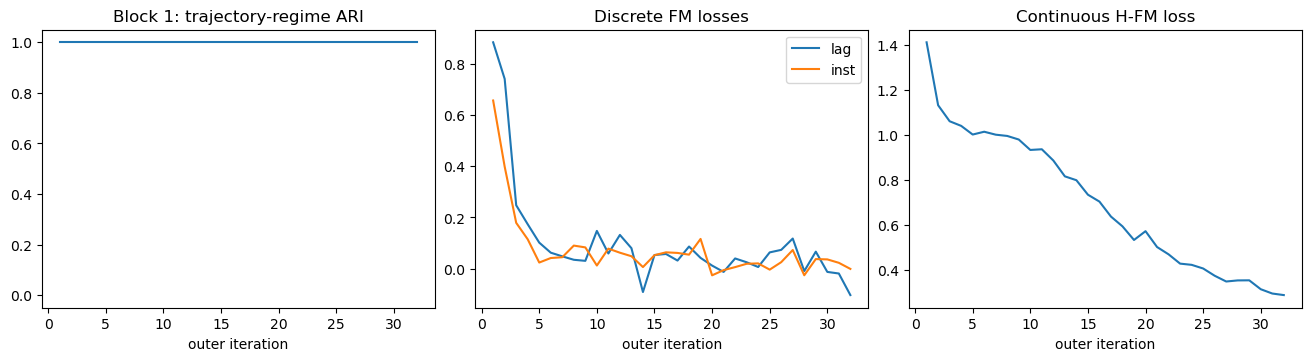

In [16]:

display(pd.DataFrame({
    "component": np.arange(K_FIT)+1,
    "pi": result["pi"],
    "effective N": result["gamma"].sum(0),
    "graph pair index": result["pairs"],
    "distance to truth 1": [graph_dist_to_truth(j)[0] for j in result["pairs"]],
    "distance to truth 2": [graph_dist_to_truth(j)[1] for j in result["pairs"]],
}))

tr = result["trace"]
fig,axes = plt.subplots(1,3,figsize=(13,3.5),constrained_layout=True)
axes[0].plot(tr["outer"],tr["ARI"])
axes[0].set_title("Block 1: trajectory-regime ARI")
axes[0].set_ylim(-.05,1.05)
axes[1].plot(tr["outer"],tr["fm_lag"],label="lag")
axes[1].plot(tr["outer"],tr["fm_inst"],label="inst")
axes[1].set_title("Discrete FM losses")
axes[1].legend()
axes[2].plot(tr["outer"],tr["fm_H"])
axes[2].set_title("Continuous H-FM loss")
for ax in axes: ax.set_xlabel("outer iteration")
plt.show()


## 12. Conditional FM posterior generation on the independent test set

In [17]:

def prepare_context_for_test(enc,state,context_net,Y_arr,I_arr):
    Y_list = [Y_arr[i] for i in range(len(Y_arr))]
    zpad,mask = encode_y_list_to_padded_z(enc,state,Y_list)
    I_t = torch.tensor(I_arr,dtype=torch.float32,device=device)
    context_net.eval()
    with torch.no_grad():
        c = context_net(zpad,mask,I_t)
    context_net.train()
    return c

def sample_graph_jump(g, rates, valid_mask, dt):
    available = (g < .5).float() * valid_mask
    r = rates * available
    total = float(r.sum())
    if total <= 0:
        return g
    p_jump = 1. - math.exp(-FM_GEN_RATE_SCALE * total * dt)
    if np.random.rand() < p_jump:
        probs = r / r.sum()
        e = int(torch.multinomial(probs,1))
        g[e] = 1.
    return g

def sample_fm_given_context(fm,context,n_samples=1):
    fm.eval()
    out_l,out_i,out_h = [],[],[]
    dt = 1.0 / FM_GEN_STEPS

    with torch.no_grad():
        for _ in range(n_samples):
            g_l = torch.zeros(E_GRAPH,dtype=torch.float32,device=device)
            g_i = torch.zeros(E_GRAPH,dtype=torch.float32,device=device)
            h = torch.randn(H_DIM,dtype=torch.float32,device=device)

            for s in range(FM_GEN_STEPS):
                tval = (s + .5) / FM_GEN_STEPS
                t = torch.tensor([[tval]],dtype=torch.float32,device=device)
                lr_l,lr_i,vh = fm(
                    context[None,:], g_l[None,:], g_i[None,:], h[None,:], t
                )
                rate_l = torch.nn.functional.softplus(lr_l[0]) + 1e-6
                rate_i = torch.nn.functional.softplus(lr_i[0]) + 1e-6
                h = h + dt*vh[0]

                g_l = sample_graph_jump(g_l,rate_l,torch.ones_like(g_l),dt)
                valid_i = inst_valid_mask_torch(g_i[None,:])[0]
                g_i = sample_graph_jump(g_i,rate_i,valid_i,dt)

            out_l.append(g_l.cpu().numpy())
            out_i.append(g_i.cpu().numpy())
            out_h.append(h.cpu().numpy())

    fm.train()
    return np.stack(out_l),np.stack(out_i),np.stack(out_h)

test_context = prepare_context_for_test(
    result["encoder"], result["state"], result["context_net"],
    Y_test_np, I_test_np
)

G_lag_fm, G_inst_fm, H_fm = [],[],[]
sample_owner = []
for i in range(N_TEST):
    gl,gi,hh = sample_fm_given_context(
        result["fm"],test_context[i],FM_SAMPLES_PER_TEST
    )
    G_lag_fm.append(gl); G_inst_fm.append(gi); H_fm.append(hh)
    sample_owner.extend([i]*FM_SAMPLES_PER_TEST)

G_lag_fm = np.concatenate(G_lag_fm)
G_inst_fm = np.concatenate(G_inst_fm)
H_fm = np.concatenate(H_fm)
sample_owner = np.array(sample_owner)

G_lag_fm_adj = np.stack([edgevec_to_graph(g) for g in G_lag_fm])
G_inst_fm_adj = np.stack([edgevec_to_graph(g) for g in G_inst_fm])

dag_valid = np.mean([is_dag(g) for g in G_inst_fm_adj])
lag_exact = np.mean([
    np.array_equal(G_lag_fm_adj[j], TRUE_LAG[R_test_true[sample_owner[j]]])
    for j in range(len(sample_owner))
])
inst_exact = np.mean([
    np.array_equal(G_inst_fm_adj[j], TRUE_INST[R_test_true[sample_owner[j]]])
    for j in range(len(sample_owner))
])
joint_exact = np.mean([
    np.array_equal(G_lag_fm_adj[j], TRUE_LAG[R_test_true[sample_owner[j]]])
    and np.array_equal(G_inst_fm_adj[j], TRUE_INST[R_test_true[sample_owner[j]]])
    for j in range(len(sample_owner))
])

print("TEST_L =",TEST_L)
print("instantaneous DAG validity:",dag_valid)
print("conditional FM exact lag:",lag_exact)
print("conditional FM exact inst:",inst_exact)
print("conditional FM exact joint pair:",joint_exact)


TEST_L = 90
instantaneous DAG validity: 1.0
conditional FM exact lag: 0.9708333333333333
conditional FM exact inst: 0.9458333333333333
conditional FM exact joint pair: 0.925



## 13. Requested graph-distribution heatmap figure

Rows:

1. \(G^{\mathrm{lag}}\)
2. \(G^{\mathrm{inst}}\)

Columns:

1. true test distribution,
2. final Block-1 particle distribution,
3. conditional FM samples given the independent test observations.


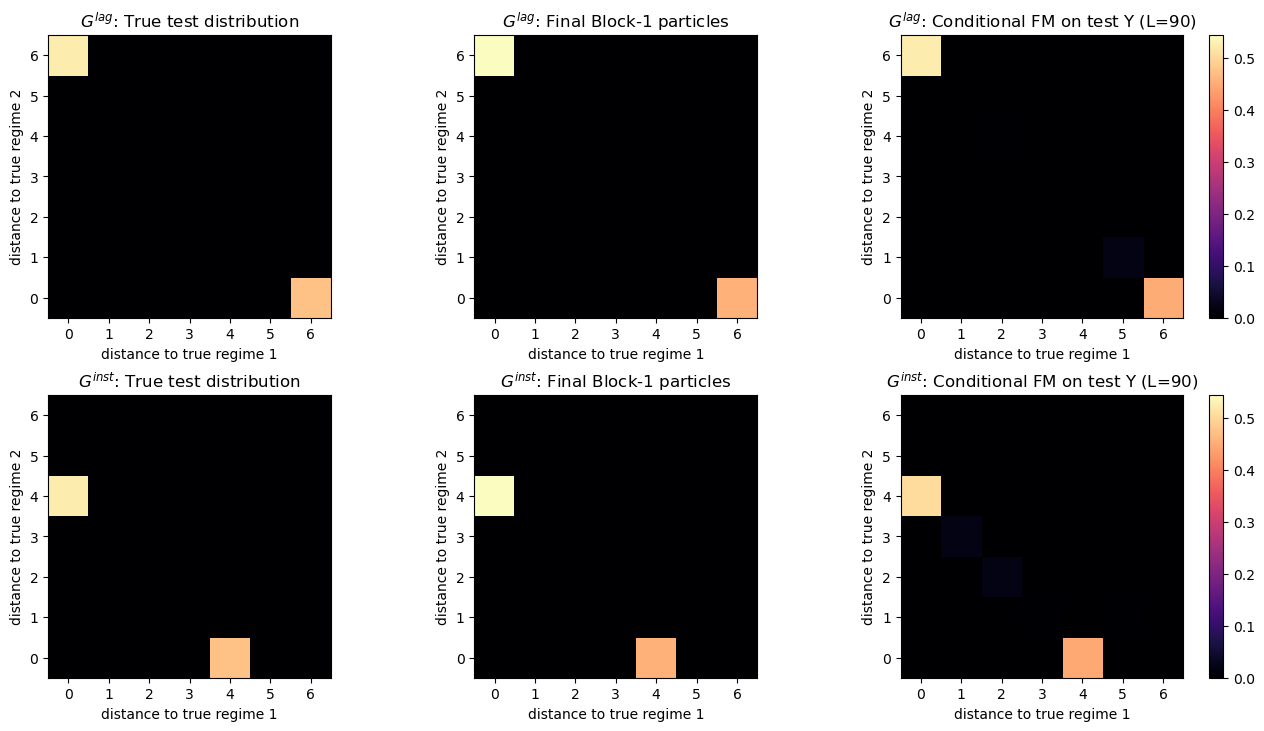

In [18]:

def graph_distance(A1,A2):
    return int(np.abs(A1-A2).sum())

MAX_GRAPH_DIST = E_GRAPH

def graph_grid(samples,true1,true2,weights=None):
    if weights is None:
        weights = np.ones(len(samples))/max(len(samples),1)
    grid = np.zeros((MAX_GRAPH_DIST+1,MAX_GRAPH_DIST+1),np.float64)
    for G,w in zip(samples,weights):
        d1 = graph_distance(G,true1)
        d2 = graph_distance(G,true2)
        if d1 <= MAX_GRAPH_DIST and d2 <= MAX_GRAPH_DIST:
            grid[d2,d1] += float(w)
    return grid

true_lag_samples = np.stack([TRUE_LAG[r] for r in R_test_true])
true_inst_samples = np.stack([TRUE_INST[r] for r in R_test_true])

particle_lag = []
particle_inst = []
particle_w = []
for r,j in enumerate(result["pairs"]):
    Gl,Gi = GRAPH_PAIRS[int(j)]
    particle_lag.append(Gl)
    particle_inst.append(Gi)
    particle_w.append(result["pi"][r])
particle_lag = np.stack(particle_lag)
particle_inst = np.stack(particle_inst)
particle_w = np.array(particle_w)
particle_w /= particle_w.sum()

lag_grids = [
    graph_grid(true_lag_samples,TRUE_LAG[0],TRUE_LAG[1]),
    graph_grid(particle_lag,TRUE_LAG[0],TRUE_LAG[1],particle_w),
    graph_grid(G_lag_fm_adj,TRUE_LAG[0],TRUE_LAG[1]),
]
inst_grids = [
    graph_grid(true_inst_samples,TRUE_INST[0],TRUE_INST[1]),
    graph_grid(particle_inst,TRUE_INST[0],TRUE_INST[1],particle_w),
    graph_grid(G_inst_fm_adj,TRUE_INST[0],TRUE_INST[1]),
]

fig,axes = plt.subplots(2,3,figsize=(13.5,7.2),constrained_layout=True)
titles = [
    "True test distribution",
    "Final Block-1 particles",
    f"Conditional FM on test Y (L={TEST_L})",
]
for row,(grids,rowname) in enumerate([
    (lag_grids,r"$G^{lag}$"),
    (inst_grids,r"$G^{inst}$"),
]):
    vmax = max(g.max() for g in grids)
    for col,(grid,title) in enumerate(zip(grids,titles)):
        im = axes[row,col].imshow(
            grid,origin="lower",cmap="magma",vmin=0,vmax=vmax
        )
        axes[row,col].set_title(f"{rowname}: {title}")
        axes[row,col].set_xlabel("distance to true regime 1")
        axes[row,col].set_ylabel("distance to true regime 2")
        axes[row,col].set_xticks(range(MAX_GRAPH_DIST+1))
        axes[row,col].set_yticks(range(MAX_GRAPH_DIST+1))
    fig.colorbar(im,ax=axes[row,:].ravel().tolist(),fraction=.025,pad=.02)
plt.show()


Selected test trajectories:
  true regime 1: test index=2, I=[0, 0, 1], length=90
  true regime 2: test index=0, I=[0, 0, 0], length=90


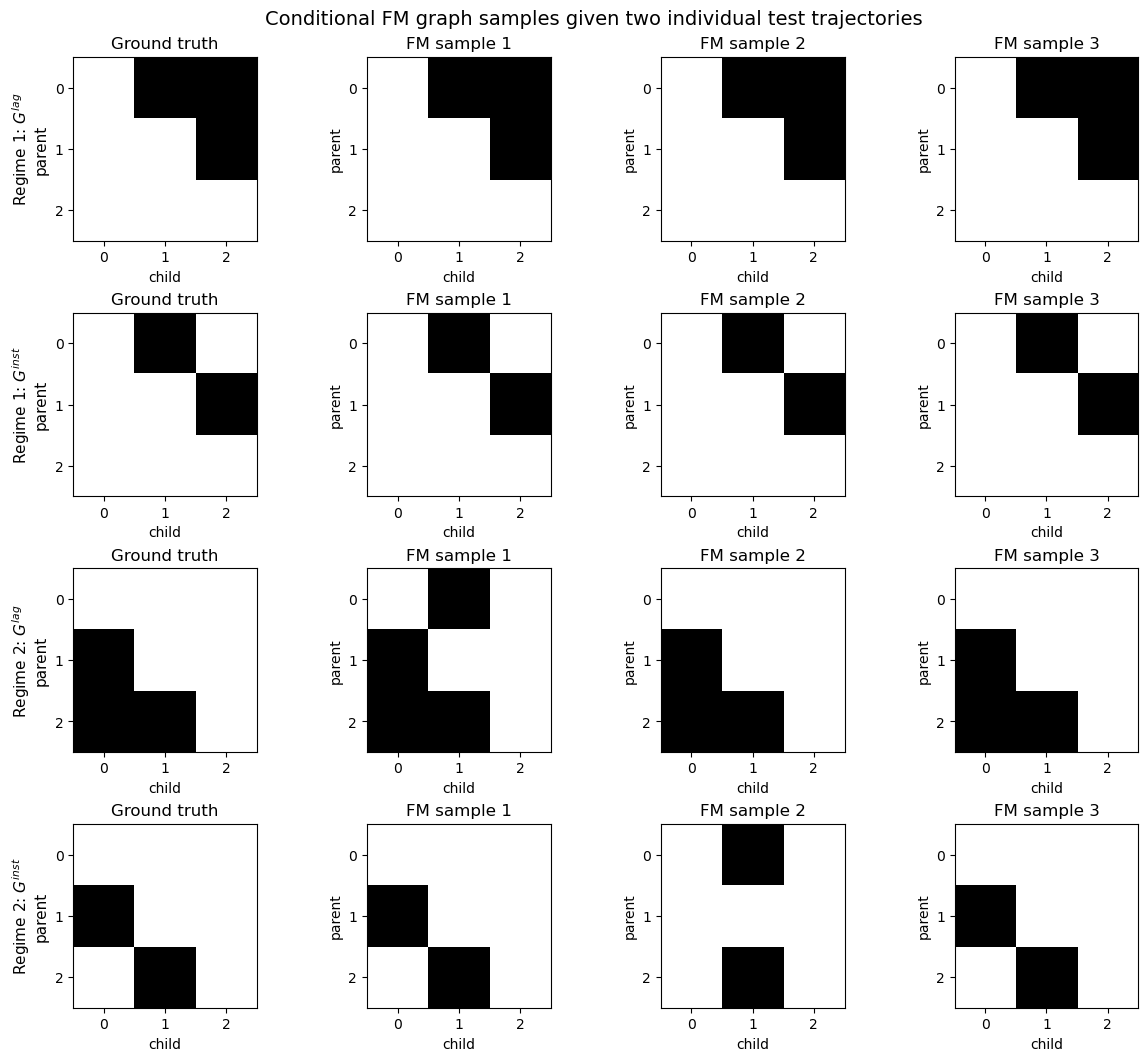

In [19]:
# ============================================================
# Conditional FM graph samples for two representative test trajectories
# One trajectory from each true regime; 3 posterior samples each
# ============================================================

N_GRAPH_SAMPLES_SHOW = 3

# Pick one test trajectory from each true regime.
test_idx_r1 = int(np.where(R_test_true == 0)[0][0])
test_idx_r2 = int(np.where(R_test_true == 1)[0][0])
chosen_test_idx = [test_idx_r1, test_idx_r2]

print("Selected test trajectories:")
for q, idx in enumerate(chosen_test_idx):
    print(
        f"  true regime {q+1}: test index={idx}, "
        f"I={I_test_np[idx].astype(int).tolist()}, "
        f"length={len(Y_test_np[idx])}"
    )

# The test contexts were already computed in Section 12.
graph_samples = {}

for q, idx in enumerate(chosen_test_idx):
    gl, gi, _ = sample_fm_given_context(
        result["fm"],
        test_context[idx],
        n_samples=N_GRAPH_SAMPLES_SHOW,
    )

    graph_samples[q] = dict(
        lag=np.stack([edgevec_to_graph(x) for x in gl]),
        inst=np.stack([edgevec_to_graph(x) for x in gi]),
    )

# ------------------------------------------------------------
# Plot: 4 rows x (truth + 3 FM samples)
# ------------------------------------------------------------
fig, axes = plt.subplots(
    4,
    1 + N_GRAPH_SAMPLES_SHOW,
    figsize=(3.0 * (1 + N_GRAPH_SAMPLES_SHOW), 10.5),
    constrained_layout=True,
)

row_specs = [
    (0, "lag",  TRUE_LAG[0],  r"Regime 1: $G^{lag}$"),
    (0, "inst", TRUE_INST[0], r"Regime 1: $G^{inst}$"),
    (1, "lag",  TRUE_LAG[1],  r"Regime 2: $G^{lag}$"),
    (1, "inst", TRUE_INST[1], r"Regime 2: $G^{inst}$"),
]

for row, (regime_idx, graph_type, G_true, row_label) in enumerate(row_specs):

    # Ground truth
    axes[row, 0].imshow(
        G_true,
        vmin=0,
        vmax=1,
        cmap="Greys",
    )
    axes[row, 0].set_title("Ground truth")

    # Conditional FM samples
    for s in range(N_GRAPH_SAMPLES_SHOW):
        Gs = graph_samples[regime_idx][graph_type][s]

        axes[row, s + 1].imshow(
            Gs,
            vmin=0,
            vmax=1,
            cmap="Greys",
        )
        axes[row, s + 1].set_title(f"FM sample {s+1}")

    for col in range(1 + N_GRAPH_SAMPLES_SHOW):
        ax = axes[row, col]
        ax.set_xticks(range(A))
        ax.set_yticks(range(A))
        ax.set_xlabel("child")
        ax.set_ylabel("parent")

    axes[row, 0].set_ylabel(
        row_label + "\nparent",
        fontsize=11,
    )

plt.suptitle(
    "Conditional FM graph samples given two individual test trajectories",
    fontsize=14,
)
plt.show()

## 14. H and variable-length diagnostics

In [20]:

def true_H_raw_vector(r):
    vals = []
    for a in range(A):
        beta = np.zeros(CANON,np.float32)
        beta[0] = true_bias[r][a]
        beta[1] = true_self[r][a]
        for k in range(A):
            beta[2+k] = true_lag_coef[r][k,a] * TRUE_LAG[r][k,a]
            beta[2+A+k] = true_inst_coef[r][k,a] * TRUE_INST[r][k,a]
        vals.extend(beta.tolist())
        vals.extend([
            np.log(true_noise_sd[r][a]**2),
            true_int_mean[a],
            np.log(true_int_sd[a]**2),
        ])
    return np.asarray(vals,np.float32)

TRUE_H_SCALED = np.stack([
    true_H_raw_vector(r)/H_SCALE_VEC for r in range(K_DATA)
])

h_rmse = np.sqrt(np.mean([
    np.mean((H_fm[j]-TRUE_H_SCALED[R_test_true[sample_owner[j]]])**2)
    for j in range(len(H_fm))
]))
print("standardized H RMSE to the true test regime:",h_rmse)

print(
    "\nTo test a different recording duration, change only TEST_L near the top and rerun.\n"
    "The conditioner accepts arbitrary length. For substantial extrapolation beyond "
    "FM_SIM_LENGTHS, extend FM_SIM_LENGTHS so training covers that duration range."
)


standardized H RMSE to the true test regime: 1.0181302

To test a different recording duration, change only TEST_L near the top and rerun.
The conditioner accepts arbitrary length. For substantial extrapolation beyond FM_SIM_LENGTHS, extend FM_SIM_LENGTHS so training covers that duration range.


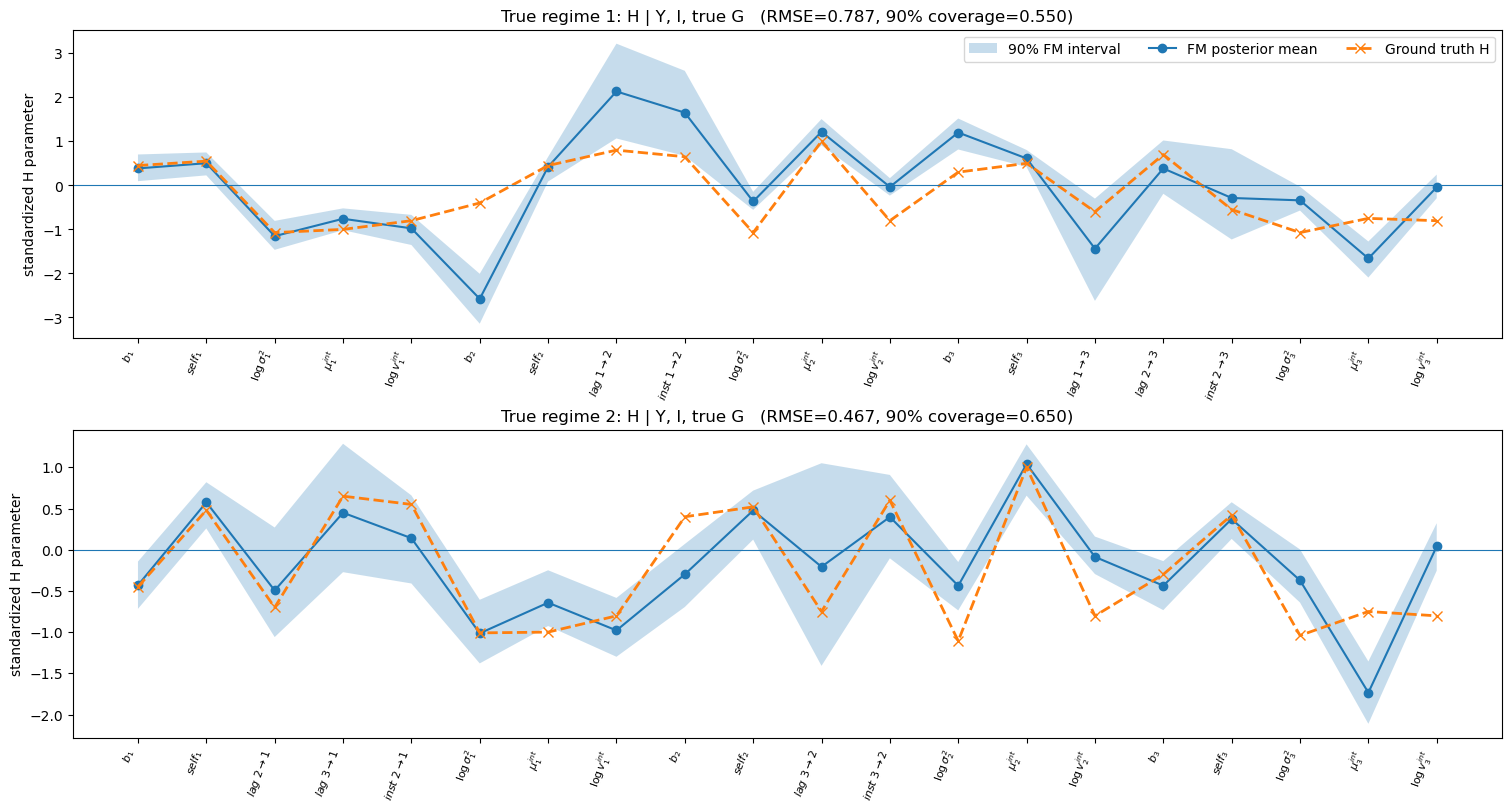

,true regime,test trajectory index,I,active H dimensions,posterior mean RMSE,90% interval coverage
0,1,2,"[0, 0, 1]",20,0.787172,0.55
1,2,0,"[0, 0, 0]",20,0.466693,0.65


In [21]:
# ============================================================
# Conditional FM diagnostic for H given the GROUND-TRUTH graphs
#
# Approximate:
#   p(H | Y_i, I_i, G_lag=true, G_inst=true)
#
# The graph flow is clamped to a random target-subgraph bridge,
# matching the conditional graph path used during FM training.
# ============================================================

N_H_SAMPLES = 100
H_INTERVAL = (0.05, 0.95)


def sample_H_given_fixed_graph(
    fm,
    context,
    G_lag_target,
    G_inst_target,
    n_samples=100,
):
    """
    Sample H while conditioning the joint FM on fixed terminal graphs.

    For each sample:
      - draw h_0 ~ N(0, I)
      - draw one random arrival time for every target graph edge
      - at each integration time t, use the corresponding target subgraph
      - integrate only the H velocity

    Since G_inst(t) is always a subgraph of the target DAG,
    every intermediate instantaneous graph is also a DAG.
    """

    fm.eval()

    g1_l = torch.tensor(
        graph_to_edgevec(G_lag_target),
        dtype=torch.float32,
        device=device,
    )
    g1_i = torch.tensor(
        graph_to_edgevec(G_inst_target),
        dtype=torch.float32,
        device=device,
    )

    samples = []
    dt = 1.0 / FM_GEN_STEPS

    with torch.no_grad():

        for _ in range(n_samples):

            # Continuous source
            h = torch.randn(
                H_DIM,
                dtype=torch.float32,
                device=device,
            )

            # Random bridge times for target edges.
            # Non-target edges remain absent forever.
            arrival_l = torch.rand(
                E_GRAPH,
                device=device,
            )
            arrival_i = torch.rand(
                E_GRAPH,
                device=device,
            )

            for s in range(FM_GEN_STEPS):

                tval = (s + 0.5) / FM_GEN_STEPS

                # Target-subgraph bridge
                g_l_t = (
                    (arrival_l <= tval).float()
                    * g1_l
                )

                g_i_t = (
                    (arrival_i <= tval).float()
                    * g1_i
                )

                t = torch.tensor(
                    [[tval]],
                    dtype=torch.float32,
                    device=device,
                )

                _, _, v_h = fm(
                    context[None, :],
                    g_l_t[None, :],
                    g_i_t[None, :],
                    h[None, :],
                    t,
                )

                h = h + dt * v_h[0]

            samples.append(h.cpu().numpy())

    fm.train()

    return np.stack(samples)


def H_parameter_labels():
    """Labels matching the packed H vector in v114."""
    labels = []

    for a in range(A):

        labels.append(fr"$b_{{{a+1}}}$")
        labels.append(fr"$self_{{{a+1}}}$")

        for k in range(A):
            labels.append(
                fr"$lag\ {k+1}\to{a+1}$"
            )

        for k in range(A):
            labels.append(
                fr"$inst\ {k+1}\to{a+1}$"
            )

        labels.extend([
            fr"$\log\sigma^2_{{{a+1}}}$",
            fr"$\mu^{{int}}_{{{a+1}}}$",
            fr"$\log v^{{int}}_{{{a+1}}}$",
        ])

    return np.array(labels)


# Reuse the two representative trajectories selected in the previous cell.
if "chosen_test_idx" not in globals():
    test_idx_r1 = int(np.where(R_test_true == 0)[0][0])
    test_idx_r2 = int(np.where(R_test_true == 1)[0][0])
    chosen_test_idx = [test_idx_r1, test_idx_r2]

h_labels = H_parameter_labels()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    constrained_layout=True,
)

h_diagnostics = {}

for regime_idx, test_idx in enumerate(chosen_test_idx):

    # --------------------------------------------------------
    # Draw conditional H samples with the TRUE graph pair fixed
    # --------------------------------------------------------
    h_samples = sample_H_given_fixed_graph(
        result["fm"],
        test_context[test_idx],
        TRUE_LAG[regime_idx],
        TRUE_INST[regime_idx],
        n_samples=N_H_SAMPLES,
    )

    # Ground-truth H in the same standardized coordinates used by FM
    h_true = TRUE_H_SCALED[regime_idx]

    # Only diagnose dimensions that are meaningful under the true graph
    active_mask = H_target_mask(
        TRUE_LAG[regime_idx],
        TRUE_INST[regime_idx],
    ).astype(bool)

    idx_active = np.where(active_mask)[0]

    h_mean = h_samples.mean(axis=0)
    h_lo = np.quantile(
        h_samples,
        H_INTERVAL[0],
        axis=0,
    )
    h_hi = np.quantile(
        h_samples,
        H_INTERVAL[1],
        axis=0,
    )

    rmse = np.sqrt(
        np.mean(
            (
                h_mean[idx_active]
                - h_true[idx_active]
            ) ** 2
        )
    )

    coverage = np.mean(
        (h_true[idx_active] >= h_lo[idx_active])
        &
        (h_true[idx_active] <= h_hi[idx_active])
    )

    h_diagnostics[regime_idx] = dict(
        samples=h_samples,
        mean=h_mean,
        lower=h_lo,
        upper=h_hi,
        active_idx=idx_active,
        rmse=rmse,
        coverage=coverage,
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    ax = axes[regime_idx]
    x = np.arange(len(idx_active))

    ax.fill_between(
        x,
        h_lo[idx_active],
        h_hi[idx_active],
        alpha=0.25,
        label="90% FM interval",
    )

    ax.plot(
        x,
        h_mean[idx_active],
        "o-",
        label="FM posterior mean",
    )

    ax.plot(
        x,
        h_true[idx_active],
        "x--",
        linewidth=2,
        markersize=7,
        label="Ground truth H",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        h_labels[idx_active],
        rotation=70,
        ha="right",
        fontsize=8,
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_title(
        f"True regime {regime_idx+1}: "
        f"H | Y, I, true G   "
        f"(RMSE={rmse:.3f}, "
        f"90% coverage={coverage:.3f})"
    )

    ax.set_ylabel("standardized H parameter")

    if regime_idx == 0:
        ax.legend(ncol=3)

plt.show()

# Numerical summary
display(pd.DataFrame([
    {
        "true regime": r + 1,
        "test trajectory index": chosen_test_idx[r],
        "I": I_test_np[chosen_test_idx[r]].astype(int).tolist(),
        "active H dimensions": len(h_diagnostics[r]["active_idx"]),
        "posterior mean RMSE": h_diagnostics[r]["rmse"],
        "90% interval coverage": h_diagnostics[r]["coverage"],
    }
    for r in range(K_DATA)
]))